# Model Evaluation and Explainability
In-depth evaluation: threshold analysis, SHAP, error audit, clinical interpretation.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../..")); os.chdir(os.path.abspath("../..."))
import warnings; warnings.filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, ConfusionMatrixDisplay
from src.data.loader import load_config, load_raw_data, preprocess_raw, split_features_target
from src.features.engineer import add_engineered_features
from sklearn.model_selection import train_test_split

config = load_config("configs/config.yaml")
df = load_raw_data(config["paths"]["raw_data"])
df = preprocess_raw(df, config)
X, y = split_features_target(df, config)
X = add_engineered_features(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline = joblib.load("artifacts/models/fertility_classifier_v1.pkl")
y_prob = pipeline.predict_proba(X_test)[:, 1]
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

Test AUC: 0.9504


## 1. ROC and Precision-Recall Curves

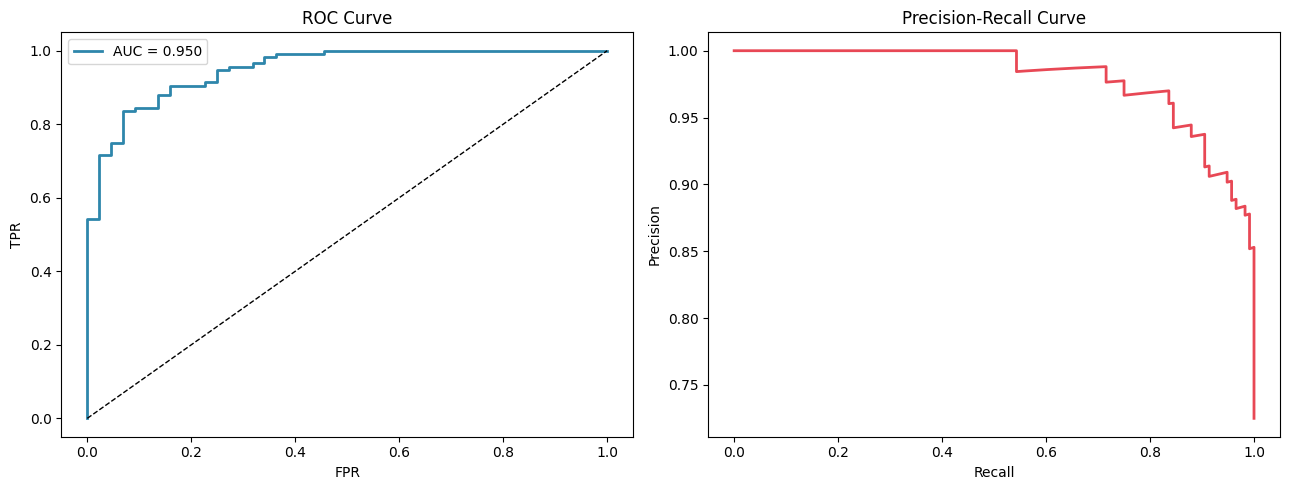

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#2E86AB", lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()
axes[1].plot(rec, prec, color="#E84855", lw=2)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("artifacts/plots/eval_roc_pr.png", bbox_inches="tight")
plt.show()

## 2. Threshold Sensitivity Analysis
In fertility counseling, **missing a high-risk couple** (predicting Success when outcome is Failure) delays intervention. Lower threshold maximizes recall for the Failure class.

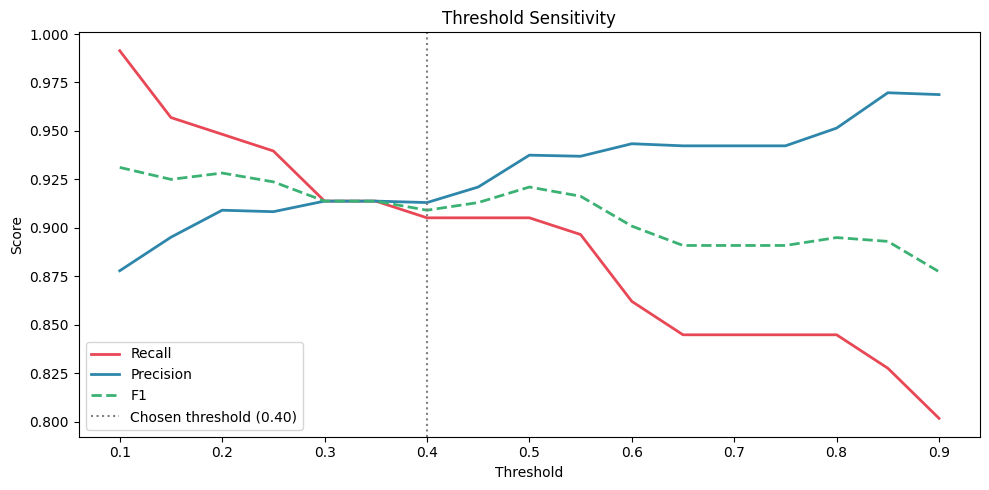

 threshold   recall  precision       f1
      0.10 0.991379   0.877863 0.931174
      0.15 0.956897   0.895161 0.925000
      0.20 0.948276   0.909091 0.928270
      0.25 0.939655   0.908333 0.923729
      0.30 0.913793   0.913793 0.913793
      0.35 0.913793   0.913793 0.913793
      0.40 0.905172   0.913043 0.909091
      0.45 0.905172   0.921053 0.913043
      0.50 0.905172   0.937500 0.921053
      0.55 0.896552   0.936937 0.916300
      0.60 0.862069   0.943396 0.900901
      0.65 0.844828   0.942308 0.890909
      0.70 0.844828   0.942308 0.890909
      0.75 0.844828   0.942308 0.890909
      0.80 0.844828   0.951456 0.894977
      0.85 0.827586   0.969697 0.893023
      0.90 0.801724   0.968750 0.877358


In [4]:
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []
for t in thresholds:
    p = (y_prob >= t).astype(int)
    tp = ((p==1)&(y_test==1)).sum(); fp = ((p==1)&(y_test==0)).sum()
    fn = ((p==0)&(y_test==1)).sum()
    recall = tp/(tp+fn) if (tp+fn)>0 else 0
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0
    rows.append({"threshold":round(t,2),"recall":recall,"precision":precision,"f1":f1})
res = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res.threshold, res.recall, label="Recall", color="#E84855", lw=2)
ax.plot(res.threshold, res.precision, label="Precision", color="#2E86AB", lw=2)
ax.plot(res.threshold, res.f1, label="F1", color="#3BB273", lw=2, linestyle="--")
ax.axvline(0.40, color="grey", linestyle=":", label="Chosen threshold (0.40)")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity"); ax.legend()
plt.tight_layout()
plt.savefig("artifacts/plots/eval_threshold_sensitivity.png", bbox_inches="tight")
plt.show()
print(res.to_string(index=False))

## 3. Confusion Matrix at Threshold 0.40

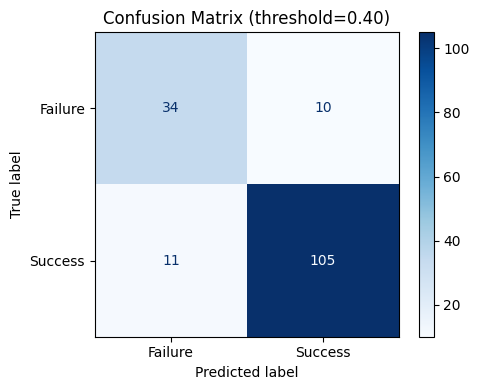

In [5]:
y_pred = (y_prob >= 0.40).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Failure","Success"],
                                         cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix (threshold=0.40)")
plt.tight_layout()
plt.savefig("artifacts/plots/eval_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 4. SHAP Explainability

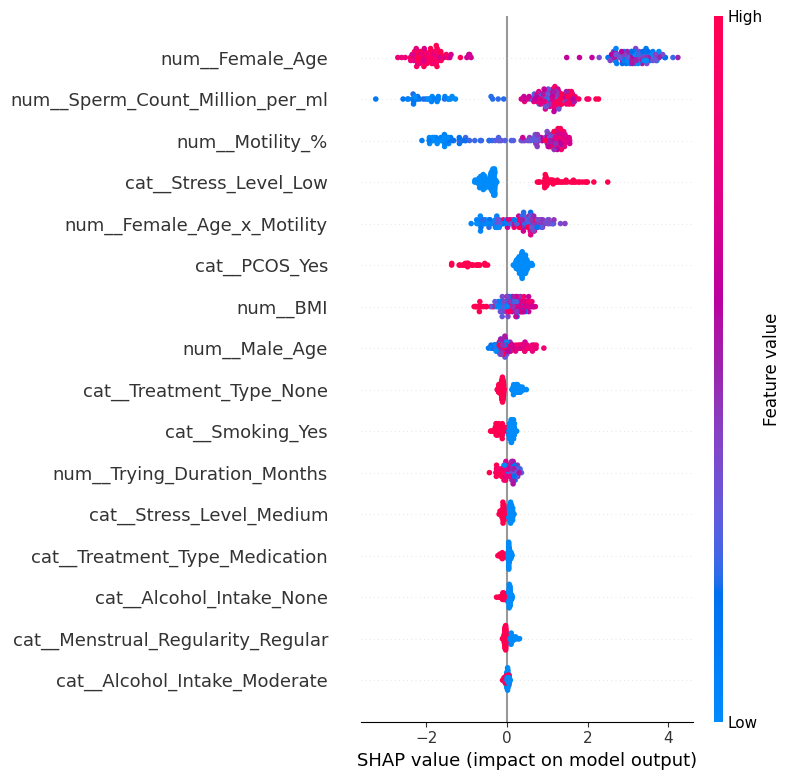

In [6]:
try:
    import shap
    X_t = pipeline.named_steps["preprocessor"].transform(X_test)
    feat_names = list(pipeline.named_steps["preprocessor"].get_feature_names_out())
    explainer = shap.TreeExplainer(pipeline.named_steps["classifier"])
    shap_vals = explainer.shap_values(X_t)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_t, feature_names=feat_names, show=False)
    plt.tight_layout()
    plt.savefig("artifacts/plots/eval_shap_summary.png", bbox_inches="tight")
    plt.show()
except ImportError:
    print("Install shap: pip install shap")

## 5. Error Audit -- False Negatives (Missed Failure Couples)

In [8]:
audit = X_test.copy()
audit["actual"] = y_test.values
audit["predicted"] = y_pred
audit["prob"] = y_prob
fn = audit[(audit.actual==1)&(audit.predicted==0)]
fp = audit[(audit.actual==0)&(audit.predicted==1)]
print(f"False Negatives (predicted Success, actual Failure): {len(fn)}")
print(f"False Positives (predicted Failure, actual Success): {len(fp)}")
print("False Negative Profile:")
print(fn[["Female_Age","Motility_%","Sperm_Count_Million_per_ml","prob"]].describe())

False Negatives (predicted Success, actual Failure): 11
False Positives (predicted Failure, actual Success): 10
False Negative Profile:
       Female_Age  Motility_%  Sperm_Count_Million_per_ml       prob
count   11.000000   11.000000                   11.000000  11.000000
mean    38.363636   51.509091                   76.709091   0.192923
std      5.162804   18.841149                   24.560475   0.087989
min     25.000000   22.500000                   29.200000   0.065840
25%     37.000000   42.300000                   65.800000   0.131232
50%     39.000000   43.000000                   84.800000   0.189436
75%     41.500000   65.150000                   90.900000   0.261334
max     44.000000   87.300000                  115.900000   0.364794


## Clinical Interpretation
- **False Negatives** are the highest clinical concern -- couples predicted as likely Success who actually fail
- SHAP analysis confirms Female Age and Motility are dominant drivers -- clinically sound
- Threshold 0.40 provides better recall than default 0.50 for at-risk couple identification
- IVF shows highest success rate -- treatment type is a strong signal